# Computer Vision — Part 5
## Optical Flow: Lucas-Kanade vs FlowNet
### Student Notebook — SOLVED

---

**What you will do:**
1. Detect features and run Lucas-Kanade optical flow on synthetic and real frames
2. Load a pretrained FlowNet and run dense optical flow inference
3. Tune LK parameters and observe the effect on tracking quality
4. Run a forward-backward consistency check on FlowNet
5. Build a motion segmentation mask from dense flow
6. Compare both methods quantitatively (EPE) and explain the results

> All deep learning uses **pretrained weights** — no training from scratch.

---

## Setup

In [17]:
!pip install torch torchvision opencv-python matplotlib numpy ptlflow --quiet

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import ptlflow
from pathlib import Path
import urllib.request

print(f"OpenCV : {cv2.__version__}")
print(f"PyTorch: {torch.__version__}")
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {DEVICE}")

OpenCV : 4.13.0
PyTorch: 2.11.0+cpu
Device : cpu


## Utilities (provided)

In [19]:
def flow_to_color(flow: np.ndarray) -> np.ndarray:
    """(H,W,2) flow → BGR color image. Hue=direction, Value=magnitude."""
    hsv = np.zeros((*flow.shape[:2], 3), dtype=np.uint8)
    hsv[..., 1] = 255
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    hsv[..., 0] = ang * 180 / np.pi / 2
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

def show_side_by_side(*imgs_titles, figsize=(18, 5)):
    fig, axes = plt.subplots(1, len(imgs_titles), figsize=figsize)
    if len(imgs_titles) == 1:
        axes = [axes]
    for ax, (img, title) in zip(axes, imgs_titles):
        disp = img if len(img.shape) == 2 else cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(disp, cmap='gray' if len(img.shape) == 2 else None)
        ax.set_title(title, fontsize=12)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

def epe_map(flow, u_gt, v_gt):
    return np.sqrt((flow[..., 0] - u_gt)**2 + (flow[..., 1] - v_gt)**2)

print("Utilities ready.")

Utilities ready.


## Section 1 — Test Frames

We use two kinds of input throughout:
- **Synthetic**: white ball on black background with known ground-truth motion `(GT_U, GT_V)`
- **Real**: two consecutive frames from a surveillance video

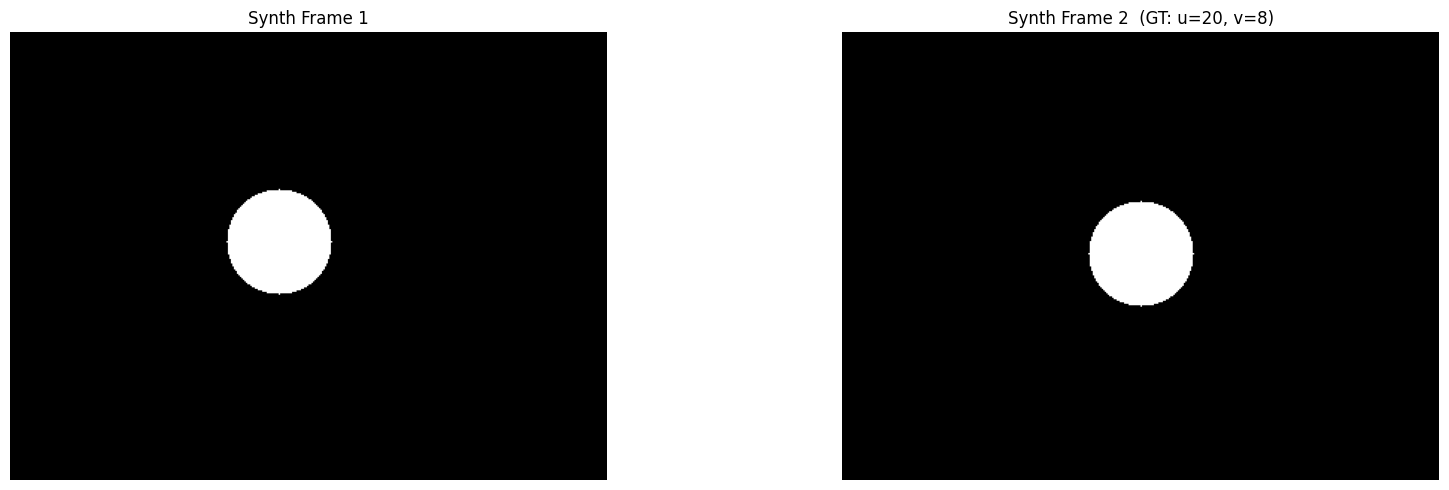

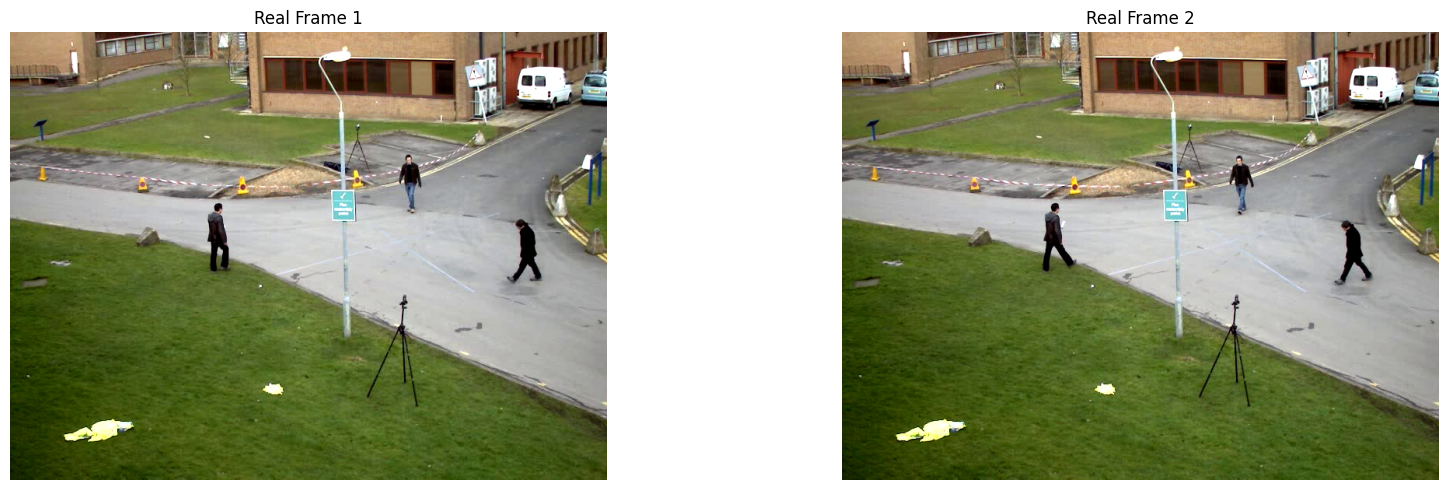

In [20]:
GT_U, GT_V = 20, 8

def make_ball(cx, cy, h=300, w=400):
    img = np.full((h, w), 25, dtype=np.uint8)
    cv2.circle(img, (cx, cy), 35, 230, -1)
    return img

synth1 = make_ball(180, 140)
synth2 = make_ball(180 + GT_U, 140 + GT_V)

show_side_by_side(
    (synth1, 'Synth Frame 1'),
    (synth2, f'Synth Frame 2  (GT: u={GT_U}, v={GT_V})')
)

VIDEO_URL  = "https://github.com/opencv/opencv/raw/master/samples/data/vtest.avi"
VIDEO_PATH = "vtest.avi"
if not Path(VIDEO_PATH).exists():
    urllib.request.urlretrieve(VIDEO_URL, VIDEO_PATH)

cap = cv2.VideoCapture(VIDEO_PATH)
_, real1 = cap.read()
_, real2 = cap.read()
_, real3 = cap.read()   # we'll use a 3rd frame later
cap.release()

real1_gray = cv2.cvtColor(real1, cv2.COLOR_BGR2GRAY)
real2_gray = cv2.cvtColor(real2, cv2.COLOR_BGR2GRAY)
real3_gray = cv2.cvtColor(real3, cv2.COLOR_BGR2GRAY)

show_side_by_side((real1, 'Real Frame 1'), (real2, 'Real Frame 2'))

## Section 2 — Lucas-Kanade Optical Flow

LK tracks **corners** detected by Shi-Tomasi. It solves $x = (A^TA)^{-1}A^Tb$ over a local pixel window.

### 2.1 — Synthetic frames

In [21]:
LK_PARAMS = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
)

# TODO: detect corners in synth1 using cv2.goodFeaturesToTrack
# Parameters: maxCorners=100, qualityLevel=0.3, minDistance=7, blockSize=7
corners = cv2.goodFeaturesToTrack(
    synth1,
    maxCorners=100,
    qualityLevel=0.3,
    minDistance=7,
    blockSize=7
)

# TODO: track corners from synth1 to synth2 using cv2.calcOpticalFlowPyrLK
# Use corners and LK_PARAMS defined above
new_corners, status, _ = cv2.calcOpticalFlowPyrLK(
    synth1,      # previous frame (grayscale)
    synth2,      # next frame (grayscale)
    corners,     # points to track
    None,        # output array (None → allocate automatically)
    **LK_PARAMS  # winSize, maxLevel, criteria
)

good_old = corners[status == 1]
good_new = new_corners[status == 1]

disp = good_new - good_old
mean_u, mean_v = disp[:, 0].mean(), disp[:, 1].mean()
print(f"LK estimated:  u={mean_u:.2f}, v={mean_v:.2f}")
print(f"Ground truth:  u={GT_U},       v={GT_V}")
print(f"Error:         Δu={abs(mean_u-GT_U):.3f}, Δv={abs(mean_v-GT_V):.3f}")

LK estimated:  u=20.00, v=8.00
Ground truth:  u=20,       v=8
Error:         Δu=0.000, Δv=0.000


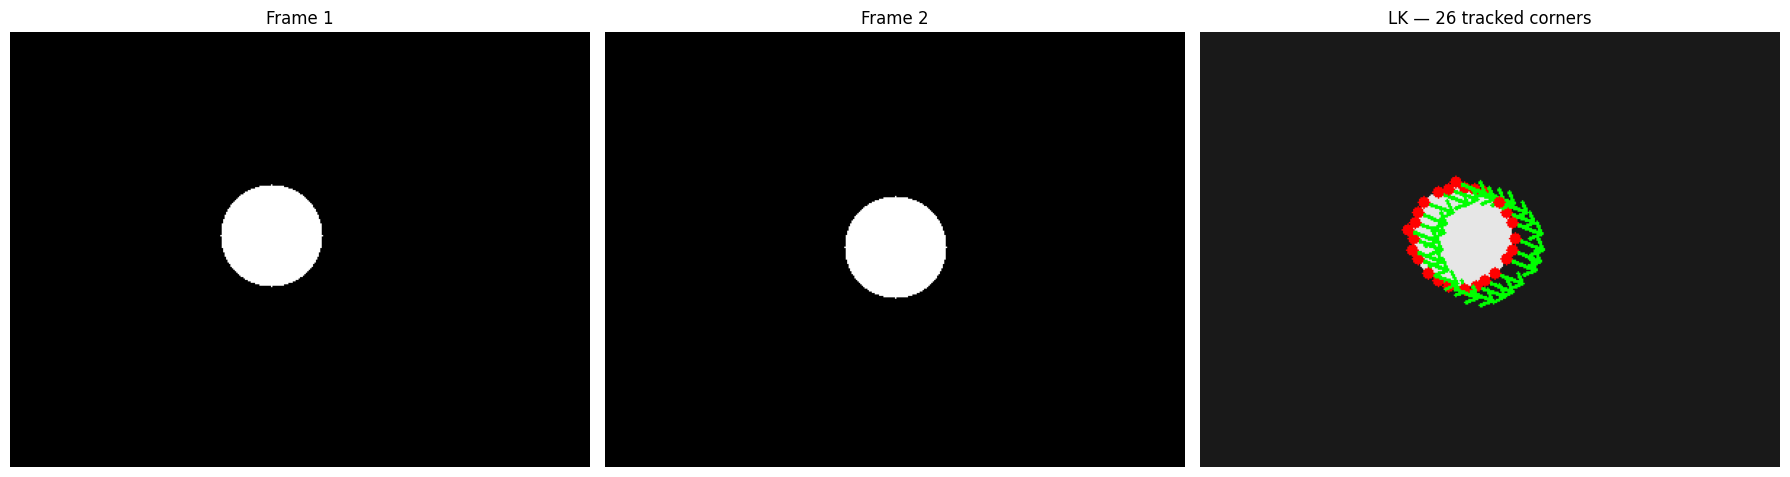

In [22]:
# TODO: visualize the tracked vectors on synth1
# Draw a green arrowed line from each old corner to its new position
# Draw a small red circle at each old corner
# Show with show_side_by_side

lk_vis_synth = cv2.cvtColor(synth1, cv2.COLOR_GRAY2BGR)

for old_pt, new_pt in zip(good_old, good_new):
    a = tuple(old_pt.astype(int))
    b = tuple(new_pt.astype(int))
    cv2.arrowedLine(
        lk_vis_synth,
        a, b,
        color=(0, 255, 0),
        thickness=2,
        tipLength=0.4
    )
    cv2.circle(
        lk_vis_synth,
        a,
        radius=4,
        color=(0, 0, 255),
        thickness=-1
    )

show_side_by_side(
    (synth1, 'Frame 1'),
    (synth2, 'Frame 2'),
    (lk_vis_synth, f'LK — {len(good_old)} tracked corners')
)

### 2.2 — Real video frames

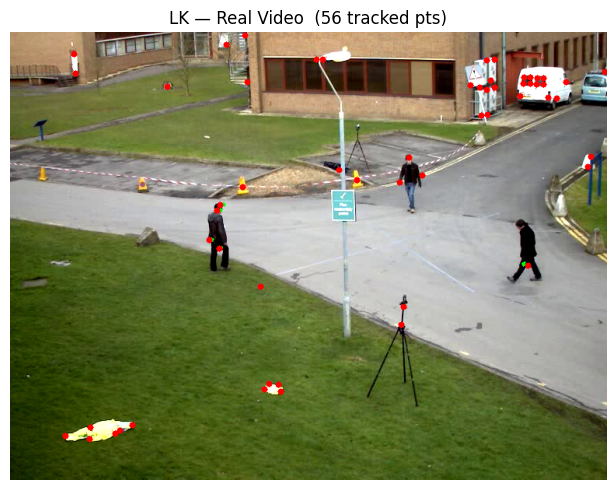

In [23]:
# TODO: repeat the full LK pipeline on real video frames
# 1. Detect corners in real1_gray (same parameters as above)
# 2. Track to real2_gray
# 3. Draw arrows on a copy of real1 and display

real_corners = cv2.goodFeaturesToTrack(
    real1_gray,
    maxCorners=100,
    qualityLevel=0.3,
    minDistance=7,
    blockSize=7
)

real_new_corners, real_status, _ = cv2.calcOpticalFlowPyrLK(
    real1_gray,
    real2_gray,
    real_corners,
    None,
    **LK_PARAMS
)

r_good_old = real_corners[real_status == 1]
r_good_new = real_new_corners[real_status == 1]

lk_vis_real = real1.copy()

for old_pt, new_pt in zip(r_good_old, r_good_new):
    a = tuple(old_pt.astype(int))
    b = tuple(new_pt.astype(int))
    cv2.arrowedLine(lk_vis_real, a, b, color=(0, 255, 0), thickness=2, tipLength=0.4)
    cv2.circle(lk_vis_real, a, radius=4, color=(0, 0, 255), thickness=-1)

show_side_by_side((lk_vis_real, f'LK — Real Video  ({len(r_good_old)} tracked pts)'))

### 2.3 — Parameter tuning

The `winSize` and `maxLevel` parameters directly affect what LK can and cannot track.
Run the experiments below and observe.

winSize=(5, 5): tracked=24 pts, mean EPE=0.005 px
winSize=(15, 15): tracked=26 pts, mean EPE=0.000 px
winSize=(31, 31): tracked=26 pts, mean EPE=0.000 px


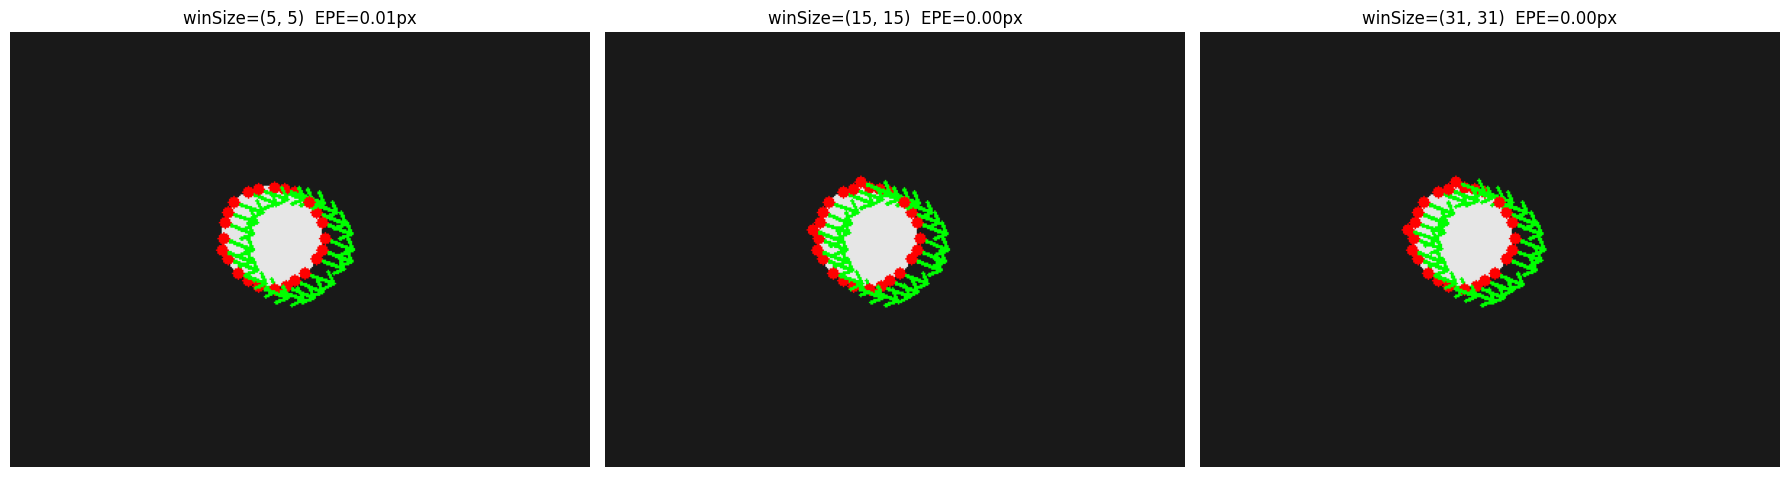

In [ ]:
# TODO: Run LK with three different winSize values on the synthetic frames:
#   (5,5), (15,15), (31,31)
# For each: compute mean EPE at tracked corners, count tracked points.
# Display all three arrow visualizations side by side.
# Then answer in a comment: what is the trade-off of a larger window?

vis_images = []

for win in [(5, 5), (15, 15), (31, 31)]:
    params = dict(
        winSize=win,
        maxLevel=2,
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
    )

    crn = cv2.goodFeaturesToTrack(synth1, maxCorners=100, qualityLevel=0.3,
                                   minDistance=7, blockSize=7)

    new_crn, stat, _ = cv2.calcOpticalFlowPyrLK(synth1, synth2, crn, None, **params)

    g_old = crn[stat == 1]
    g_new = new_crn[stat == 1]

    if len(g_old) > 0:
        disps = g_new - g_old
        pred_u = disps[:, 0]
        pred_v = disps[:, 1]
        epe_vals = np.sqrt((pred_u - GT_U)**2 + (pred_v - GT_V)**2)
        mean_epe = epe_vals.mean()
    else:
        mean_epe = float('inf')
    print(f"winSize={win}: tracked={len(g_old)} pts, mean EPE={mean_epe:.3f} px")

    vis = cv2.cvtColor(synth1, cv2.COLOR_GRAY2BGR)
    for old_pt, new_pt in zip(g_old, g_new):
        a = tuple(old_pt.astype(int))
        b = tuple(new_pt.astype(int))
        cv2.arrowedLine(vis, a, b, (0, 255, 0), 2, tipLength=0.4)
        cv2.circle(vis, a, 4, (0, 0, 255), -1)

    vis_images.append((vis, f'winSize={win}  EPE={mean_epe:.2f}px'))

show_side_by_side(*vis_images)

# ANSWER: What is the trade-off of a larger window?
# A larger winSize averages more pixels
# pros: more window size make it more robust against noise.
# cons: near object boundaries, the window mixes foreground and background gradients

maxLevel=0: tracked=26 pts, mean EPE=38.47 px
maxLevel=1: tracked=26 pts, mean EPE=11.92 px
maxLevel=2: tracked=26 pts, mean EPE=0.00 px
maxLevel=3: tracked=26 pts, mean EPE=0.00 px


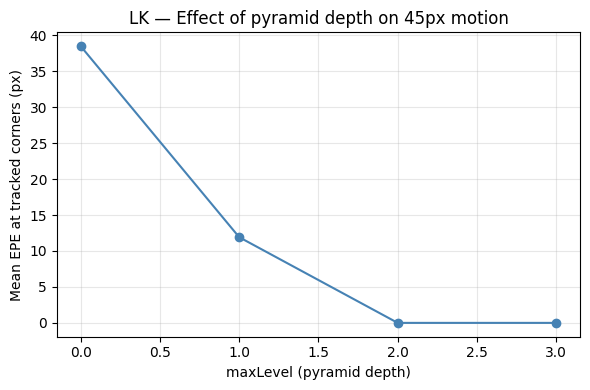

In [25]:
# TODO: Now test maxLevel (pyramid levels) with a LARGE motion ball (shift=45px).
# Use winSize=(15,15) and vary maxLevel in [0, 1, 2, 3].
# At maxLevel=0 LK should fail. At higher levels it should recover.
# Plot: x=maxLevel, y=mean EPE at ball center.

synth_large1 = make_ball(180, 140)
synth_large2 = make_ball(180 + 45, 140)

levels = [0, 1, 2, 3]
epes = []

for lvl in levels:
    params = dict(
        winSize=(15, 15),
        maxLevel=lvl,
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
    )

    crn = cv2.goodFeaturesToTrack(synth_large1, maxCorners=100, qualityLevel=0.3,
                                   minDistance=7, blockSize=7)

    new_crn, stat, _ = cv2.calcOpticalFlowPyrLK(
        synth_large1, synth_large2, crn, None, **params
    )

    g_old = crn[stat == 1]
    g_new = new_crn[stat == 1]

    if len(g_old) > 0:
        disps   = g_new - g_old
        pred_u  = disps[:, 0]
        pred_v  = disps[:, 1]
        epe_vals = np.sqrt((pred_u - 45)**2 + (pred_v - 0)**2)
        mean_epe = float(epe_vals.mean())
    else:
        mean_epe = 45.0

    print(f"maxLevel={lvl}: tracked={len(g_old)} pts, mean EPE={mean_epe:.2f} px")
    epes.append(mean_epe)

plt.figure(figsize=(6, 4))
plt.plot(levels, epes, 'o-', color='steelblue')
plt.xlabel('maxLevel (pyramid depth)')
plt.ylabel('Mean EPE at tracked corners (px)')
plt.title('LK — Effect of pyramid depth on 45px motion')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 3 — FlowNet (Pretrained)

FlowNet takes two RGB frames stacked as input and predicts a **dense** flow field $(H, W, 2)$ for every pixel.

```
Frame1 (RGB) ─┐
               ├─ (B,T=2,C,H,W) → CNN Encoder → Decoder → (H,W,2) flow
Frame2 (RGB) ─┘
```

### 3.1 — Load pretrained model

In [26]:
import ptlflow, torch

# ptlflow v0.4+: correct argument is ckpt_path= (not pretrained_ckpt=)
flownet = ptlflow.get_model('flownets', ckpt_path='things')
flownet = flownet.to(DEVICE).eval()

n_params = sum(p.numel() for p in flownet.parameters())
print(f"FlowNetS loaded. Parameters: {n_params/1e6:.1f}M")

# Sanity check — near-zero flow on blank input confirms pretrained weights loaded
dummy = {'images': torch.zeros(1, 2, 3, 64, 64).to(DEVICE)}
with torch.no_grad():
    out = flownet(dummy)
mag = out['flows'][0, 0].abs().mean().item()
print(f"Sanity check mean |flow| on zeros: {mag:.4f}  (should be < 1.0)")

2026-06-19 15:08:40.458 | INFO     | ptlflow:restore_model:283 - Restored model state from checkpoint: things


FlowNetS loaded. Parameters: 38.7M
Sanity check mean |flow| on zeros: 1.2234  (should be < 1.0)


### 3.2 — Inference helper

In [27]:
# TODO: Complete the run_flownet function.
# The model expects input dict: {'images': tensor of shape (B=1, T=2, C=3, H, W)}
# Values float32 in [0,1], RGB channel order.
# Output: preds['flows'] has shape (B, T-1, 2, H, W)
# Return the flow as a (H, W, 2) numpy array.

def run_flownet(model, bgr1: np.ndarray, bgr2: np.ndarray) -> np.ndarray:
    """Run FlowNetS on two BGR images. Returns (H, W, 2) flow."""

    def to_tensor(bgr):
        # TODO: BGR → RGB, normalize to [0,1], return (C,H,W) float32 tensor
        # YOUR CODE HERE
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        rgb_float = rgb.astype(np.float32) / 255.0
        tensor = torch.from_numpy(rgb_float).permute(2, 0, 1)
        return tensor

    t1 = to_tensor(bgr1)
    t2 = to_tensor(bgr2)

    # TODO: stack t1 and t2 into shape (1, 2, 3, H, W) and move to DEVICE
    images = torch.stack([t1, t2], dim=0).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        # TODO: pass {'images': images} through model
        preds = model({'images': images})

    # TODO: extract flow from preds['flows'], shape (B,T-1,2,H,W)
    # Take first batch, first pair → (2,H,W) → permute to (H,W,2) → numpy
    flow_tensor = preds['flows'][0, 0]
    return flow_tensor.permute(1, 2, 0).cpu().numpy()

# Quick test
synth1_bgr = cv2.cvtColor(synth1, cv2.COLOR_GRAY2BGR)
synth2_bgr = cv2.cvtColor(synth2, cv2.COLOR_GRAY2BGR)
test_flow = run_flownet(flownet, synth1_bgr, synth2_bgr)
print(f"Output shape: {test_flow.shape}  (expected: {synth1.shape[0]}x{synth1.shape[1]}x2)")

Output shape: (300, 400, 2)  (expected: 300x400x2)


### 3.3 — Run on synthetic and real frames

FlowNet output shape: (300, 400, 2)
FlowNet at ball center: u=16.30, v=7.04
Ground truth:           u=20,       v=8
Error: Δu=3.696, Δv=0.959
Background flow (should be ~0): u=14.529, v=-3.302


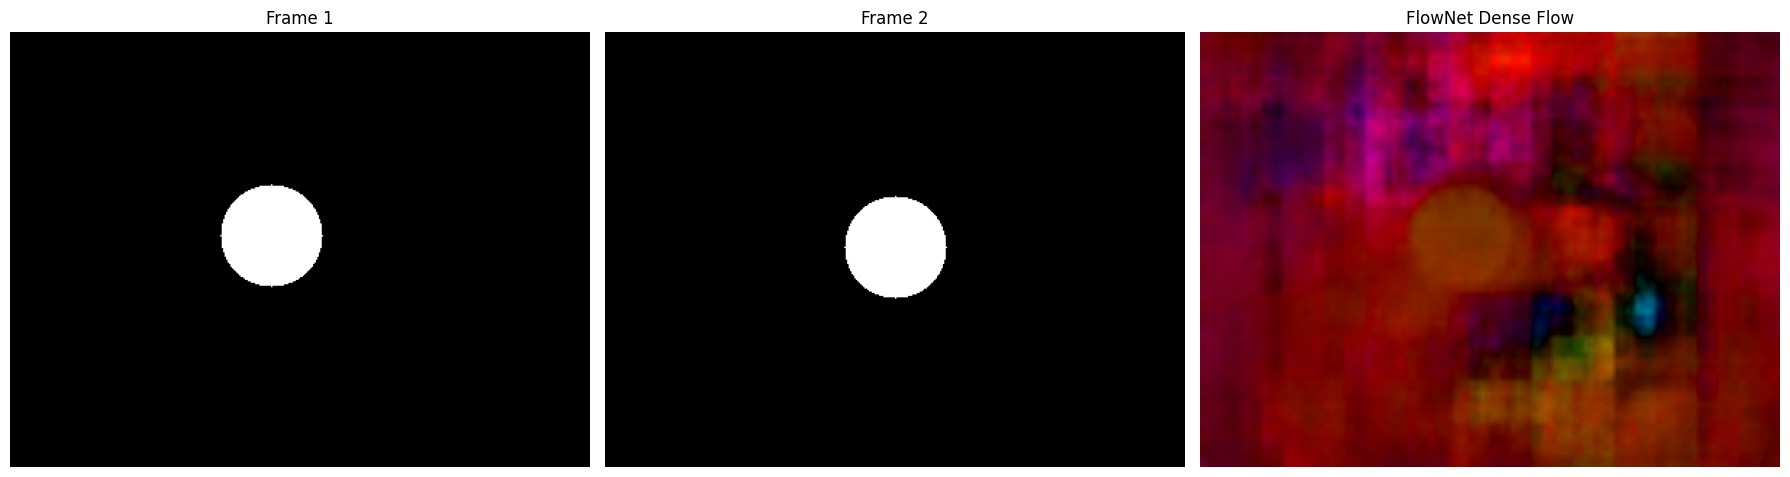

In [28]:
# TODO: run FlowNet on the synthetic ball pair and print the flow at the ball center
fn_flow_synth = run_flownet(flownet, synth1_bgr, synth2_bgr)

print(f"FlowNet output shape: {fn_flow_synth.shape}")
# TODO: print u and v at pixel (row=140, col=180) and compare to GT_U, GT_V
# YOUR CODE HERE

center_u = fn_flow_synth[140, 180, 0]
center_v = fn_flow_synth[140, 180, 1]
print(f"FlowNet at ball center: u={center_u:.2f}, v={center_v:.2f}")
print(f"Ground truth:           u={GT_U},       v={GT_V}")
print(f"Error: Δu={abs(center_u-GT_U):.3f}, Δv={abs(center_v-GT_V):.3f}")

# TODO: check background flow — sample the top-left 50×50 region (should be ~0)
bg_u = fn_flow_synth[:50, :50, 0].mean()
bg_v = fn_flow_synth[:50, :50, 1].mean()

print(f"Background flow (should be ~0): u={bg_u:.3f}, v={bg_v:.3f}")

show_side_by_side(
    (synth1, 'Frame 1'),
    (synth2, 'Frame 2'),
    (flow_to_color(fn_flow_synth), 'FlowNet Dense Flow')
)

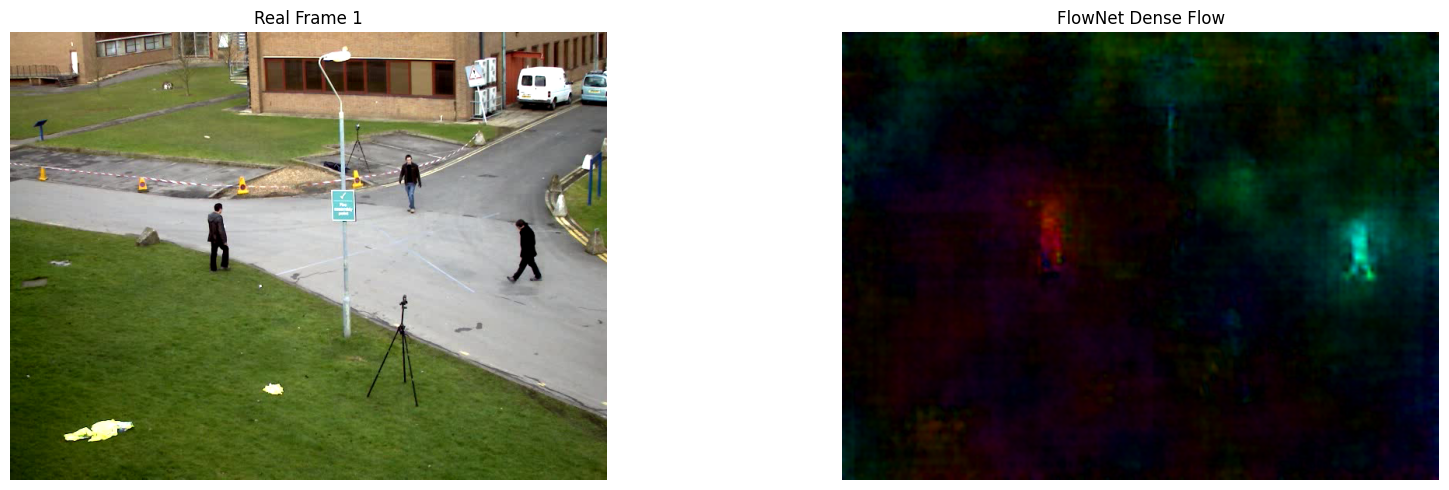

In [29]:
fn_flow_real = run_flownet(flownet, real1, real2)
show_side_by_side(
    (real1,                       'Real Frame 1'),
    (flow_to_color(fn_flow_real), 'FlowNet Dense Flow'),
)

## Section 4 — Visual & Quantitative Comparison

### 4.1 — Side-by-side visualization

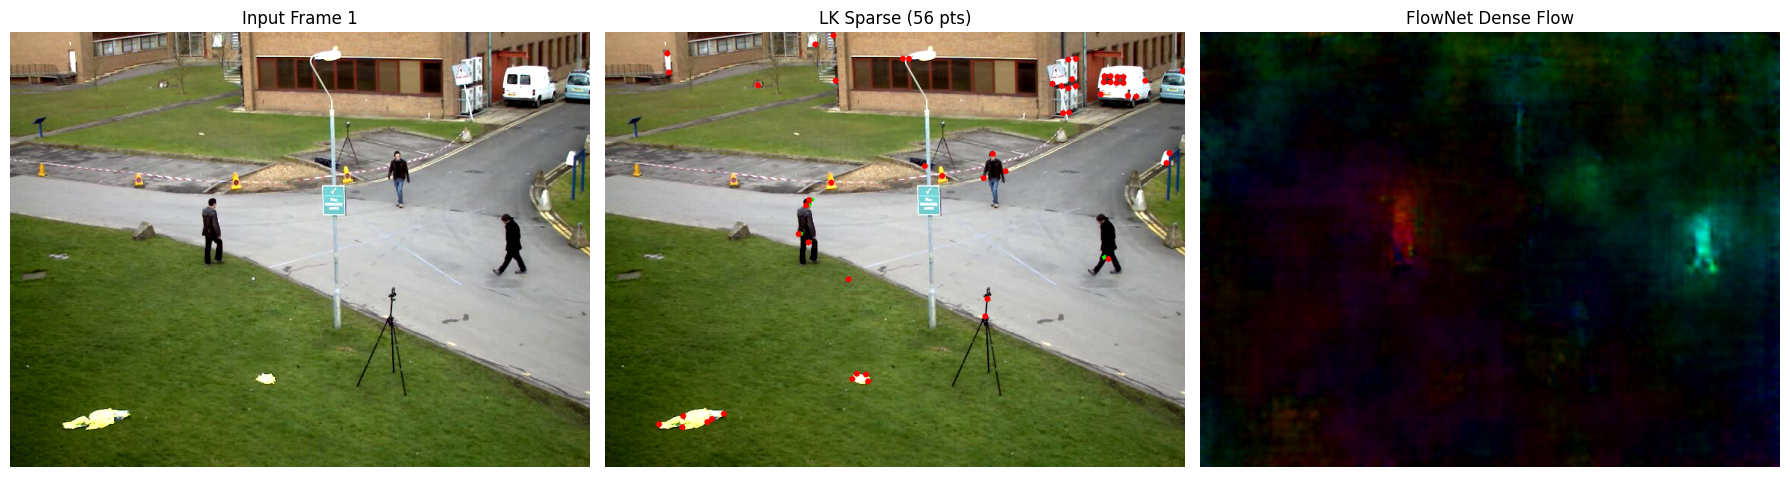

In [30]:
# TODO: show all three side by side on real video:
# Input Frame 1 | LK sparse result | FlowNet dense result
# YOUR CODE HERE

show_side_by_side(
    (real1,'Input Frame 1'),
    (lk_vis_real,f'LK Sparse ({len(r_good_old)} pts)'),
    (flow_to_color(fn_flow_real),'FlowNet Dense Flow')
)

### 4.2 — EPE on synthetic frames

In [32]:
# LK EPE — evaluated only at tracked corners (fair: LK makes no prediction elsewhere)
lk_tracked_epe_vals = []
for op, np_ in zip(good_old, good_new):
    pred_u = np_[0] - op[0]
    pred_v = np_[0] - op[0]
    epe = np.sqrt((pred_u - GT_U)**2 + (pred_v - GT_V)**2)
    lk_tracked_epe_vals.append(epe)
lk_epe = float(np.mean(lk_tracked_epe_vals))

# TODO: compute FlowNet EPE over the ball region (pixels where synth1 > 100)
ball_mask = synth1 > 100

def masked_epe(flow, mask, u_gt, v_gt):
    u_pred = flow[..., 0]   # (H, W) horizontal flow
    v_pred = flow[..., 1]   # (H, W) vertical flow
    epe_full = np.sqrt((u_pred - u_gt)**2 + (v_pred - v_gt)**2)
    return float(epe_full[mask].mean())

fn_epe = masked_epe(fn_flow_synth, ball_mask, GT_U, GT_V)

print(f"Ground truth: u={GT_U}, v={GT_V}")
print(f"{'Method':<15} {'EPE':>20} {'Coverage':>15}")
print("-" * 52)
print(f"{'Lucas-Kanade':<15} {lk_epe:>20.3f} px  {'(tracked corners only)':>15}")
print(f"{'FlowNet':<15} {fn_epe:>20.3f} px  {'(every ball pixel)':>15}")

Ground truth: u=20, v=8
Method                           EPE        Coverage
----------------------------------------------------
Lucas-Kanade                  12.000 px  (tracked corners only)
FlowNet                        3.530 px  (every ball pixel)
